In [4]:
from src.FractionsCorrelation import (
    measure_correlations_by_L_and_gap,
    summarize_gap_independence,
    read_fraction_values_by_L_and_gap,
)
import json
import matplotlib.pyplot as plt
import lzma

In [5]:
corr = measure_correlations_by_L_and_gap(
    "../SOP_data",
    measure="p_stab_bond",
    L_values=16384,
    gaps=[0.5, 1.0, 1.5, 2.0],
    lags=range(1, 11),
)

summary = summarize_gap_independence(corr)

summary[[
    "L", "gap",
    "max_abs_correlation",
    "mean_abs_correlation",
    "min_p_value",
    "gap_rank",
    "is_best_gap",
]]

,L,gap,max_abs_correlation,mean_abs_correlation,min_p_value,gap_rank,is_best_gap
0,16384,0.5,0.253895,0.085295,0.096499,1,True
1,16384,1.5,0.347650,0.180794,0.037165,2,False
2,16384,2.0,0.411539,0.102164,0.071278,3,False
3,16384,1.0,0.450213,0.149658,0.020028,4,False


p_mean = 0.5208015095103871 ± 0.0015686485607410863, σ = 0.03678806965462166
p_mean = 0.45850152535872024 ± 0.0017281345804703854, σ = 0.03624965677652306
p_mean = 0.4016196915597627 ± 0.002023645460545212, σ = 0.03676134537112495
p_mean = 0.3269271942207942 ± 0.0033350626695193585, σ = 0.04057278848469741
p_mean = 0.27487310745260296 ± 0.006323416838845907, σ = 0.036871539398365225


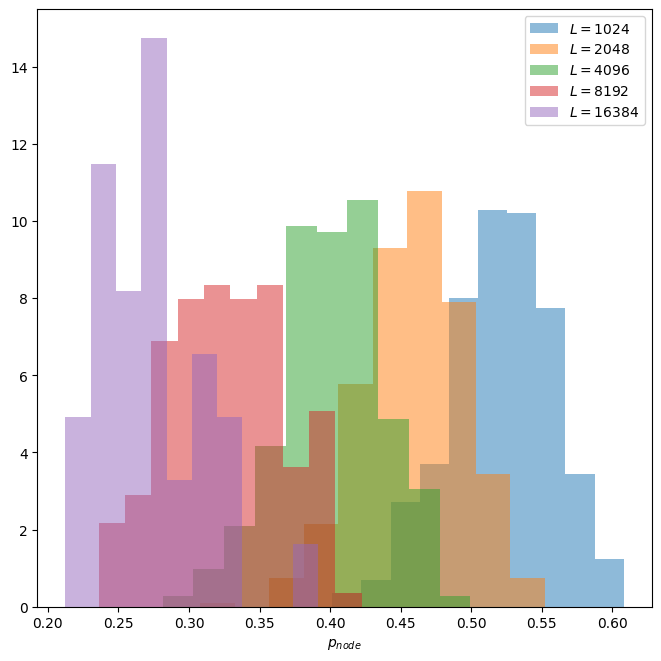

In [6]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]

base = 6.5
n_rows = 1
n_columns = 1

fs_title = 20
fs_label = 18
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*base, n_rows*base), constrained_layout=True)

gap = 1.0
prop = "p_inst_node"
p_mean_node = []
for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    p_stab = values[(L, gap)][0]["data"][prop]
    p_avarage = np.mean(p_stab)
    std = np.std(p_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))

    p_mean_node.append(p_avarage)
    print(f"p_mean = {p_avarage} ± {sem}, σ = {std}")
    axes.hist(p_stab,alpha=0.5, density=True ,label=f"$L={L}$")
    axes.set_xlabel(r'$p_{node}$')
plt.legend()
plt.show()

A = 2.688103
d = 1.766811
R² = 0.999832
RMSE(log) = 2.247177e-02


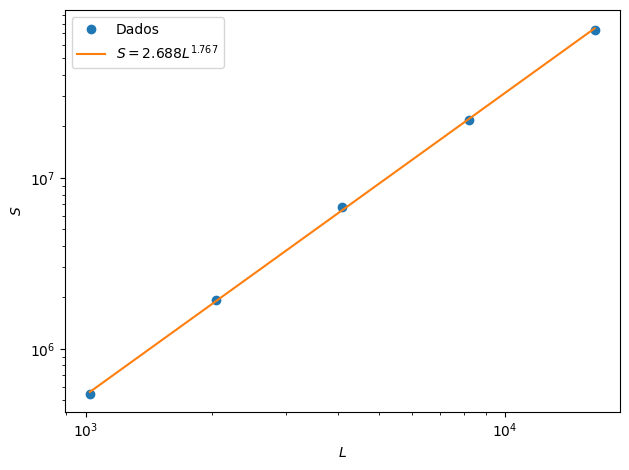

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.array(L_lst, dtype=float)
y = np.array(p_mean_node, dtype=float)*x**2

# Transformação log-log
x_log = np.log(x).reshape(-1, 1)
y_log = np.log(y)

# Ajuste linear
model = LinearRegression()
model.fit(x_log, y_log)

# Predição no espaço log
y_pred_log = model.predict(x_log)

# Parâmetros
d = model.coef_[0]
log_A = model.intercept_
A = np.exp(log_A)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

print(f"A = {A:.6f}")
print(f"d = {d:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")

# Curva ajustada no espaço original
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

# Plot
plt.plot(x, y, 'o', label='Dados')
plt.plot(
    L_fit,
    S_fit,
    '-',
    label=fr'$S = {A:.3f}L^{{{d:.3f}}}$'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$L$')
plt.ylabel(r'$S$')

plt.legend()
plt.tight_layout()

plt.show()

p_mean = 0.3107764888403761 ± 0.0004907714339584375, σ = 0.011509610341548994
p_mean = 0.27919235387008823 ± 0.0005586740708742551, σ = 0.011718846175523143
p_mean = 0.24944090358059984 ± 0.0007514093208512013, σ = 0.013650028178083772
p_mean = 0.21046992396902287 ± 0.001481815006747603, σ = 0.018027057599755845
p_mean = 0.17782068757016734 ± 0.003332973446219546, σ = 0.019434407831702933


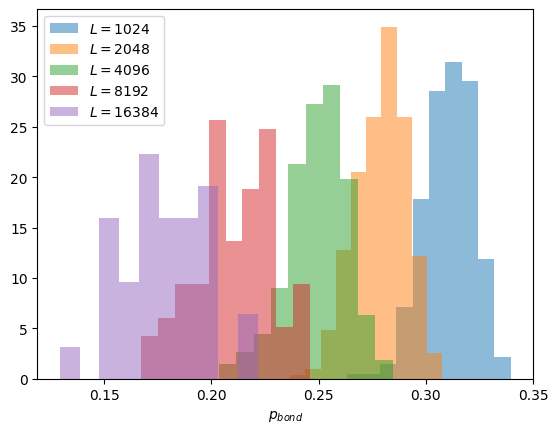

In [8]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.0
prop = "p_stab_bond"
p_mean_bond = []

for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    p_stab = values[(L, gap)][0]["data"][prop]
    p_avarage = np.mean(p_stab)
    std = np.std(p_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))
    p_mean_bond.append(p_avarage)
    
    print(f"p_mean = {p_avarage} ± {sem}, σ = {std}")
    plt.hist(p_stab, alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$p_{bond}$')
plt.legend()
plt.show()

In [9]:
#p_mean_node
R = [i/j for i,j in zip(p_mean_node, p_mean_bond)]
R

[1.675807302713578,
 1.6422424146044732,
 1.6100795250286228,
 1.5533202466919294,
 1.545788126278272]

In [ ]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.0
prop = "s_stab_bond"
p_mean_bond = []

for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    p_stab = values[(L, gap)][0]["data"][prop]
    p_avarage = np.mean(p_stab)
    std = np.std(p_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))
    p_mean_bond.append(p_avarage)
    
    print(f"p_mean = {p_avarage} ± {sem}, σ = {std}")
    plt.hist(p_stab, alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$p_{bond}$')
plt.legend()
plt.show()

# Fractal Dimension

A = 0.596421 ± 0.035179
d = 1.928591 ± 0.007520
R² = 0.999485
RMSE(log) = 4.240858e-02
χ² reduzido = 2.926676


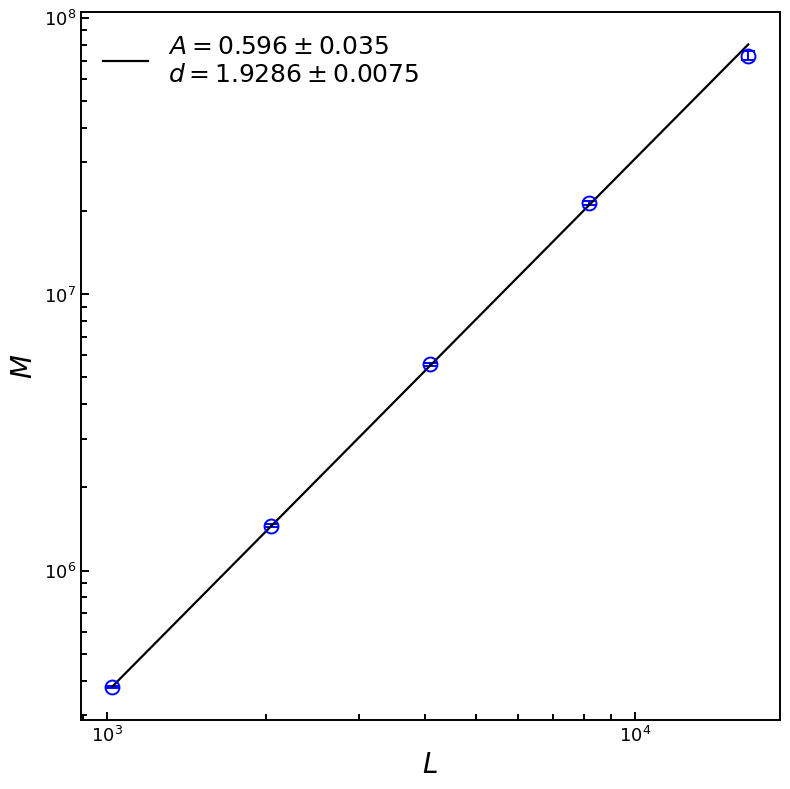

In [48]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.asarray(L_lst, dtype=float)
y = np.asarray(S_mean_node, dtype=float)
y_err = np.asarray(S_mean_node_err, dtype=float)

# Remove valores inválidos para o ajuste log-log
mask = (
    np.isfinite(x)
    & np.isfinite(y)
    & np.isfinite(y_err)
    & (x > 0)
    & (y > 0)
    & (y_err > 0)
)

x = x[mask]
y = y[mask]
y_err = y_err[mask]

# Transformação logarítmica
x_log = np.log(x)
y_log = np.log(y)

# Propagação da incerteza:
# sigma[ln(y)] ≈ sigma_y/y
y_log_err = y_err / y


# Modelo linear no espaço logarítmico
def linear_log(x_log, log_A, d):
    return log_A + d * x_log


# Ajuste ponderado
popt, pcov = curve_fit(
    linear_log,
    x_log,
    y_log,
    sigma=y_log_err,
    absolute_sigma=True
)

log_A, d = popt

# Incertezas e covariância
log_A_err, d_err = np.sqrt(np.diag(pcov))
cov_logA_d = pcov[0, 1]

# Conversão de log(A) para A
A = np.exp(log_A)
A_err = A * log_A_err

# Predição
y_pred_log = linear_log(x_log, log_A, d)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

# Qui-quadrado
chi2 = np.sum(((y_log - y_pred_log) / y_log_err)**2)
ndof = len(x) - len(popt)
chi2_red = chi2 / ndof if ndof > 0 else np.nan

print(f"A = {A:.6f} ± {A_err:.6f}")
print(f"d = {d:.6f} ± {d_err:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")
print(f"χ² reduzido = {chi2_red:.6f}")

# Curva ajustada
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

base = 4
fig, ax = plt.subplots(figsize=(2 * base, 2 * base))

ax.errorbar(
    x,
    y,
    yerr=y_err,
    fmt='o',
    ms=10,
    mec='blue',
    mfc='none',
    mew=1.4,
    ecolor='blue',
    elinewidth=1.4,
    capsize=5,
    capthick=1.4
)

ax.plot(
    L_fit,
    S_fit,
    '-',
    color='k',
    linewidth=1.6,
    label=legenda
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=20)
ax.set_ylabel(r'$M$', fontsize=20)

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    labelsize=13,
    length=6,
    width=1.4
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.4
)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

# Legenda sem caixa
ax.legend(
    fontsize=18,
    frameon=False,
    loc='upper left',
    handlelength=1.8
)

fig.tight_layout()
plt.show()

In [43]:
def formatar_parametro(valor, erro, algarismos_erro=2):
    """
    Formata valor e erro sem notação científica.
    O erro é mostrado com dois algarismos significativos.
    """
    if not np.isfinite(erro) or erro <= 0:
        return f"{valor:.4f}", f"{erro:.4f}"

    ordem = np.floor(np.log10(abs(erro)))
    casas = max(0, int(-ordem + algarismos_erro - 1))

    return (
        f"{valor:.{casas}f}",
        f"{erro:.{casas}f}"
    )


A_texto, A_erro_texto = formatar_parametro(A, A_err)
d_texto, d_erro_texto = formatar_parametro(d, d_err)

legenda = (
    fr'$A = {A_texto}\pm {A_erro_texto}$'
    '\n'
    fr'$d = {d_texto}\pm {d_erro_texto}$'
)

A = 0.596421 +/- 3.517866e-02
d = 1.928591 +/- 7.520098e-03
R² = 0.999485
RMSE(log) = 4.240858e-02


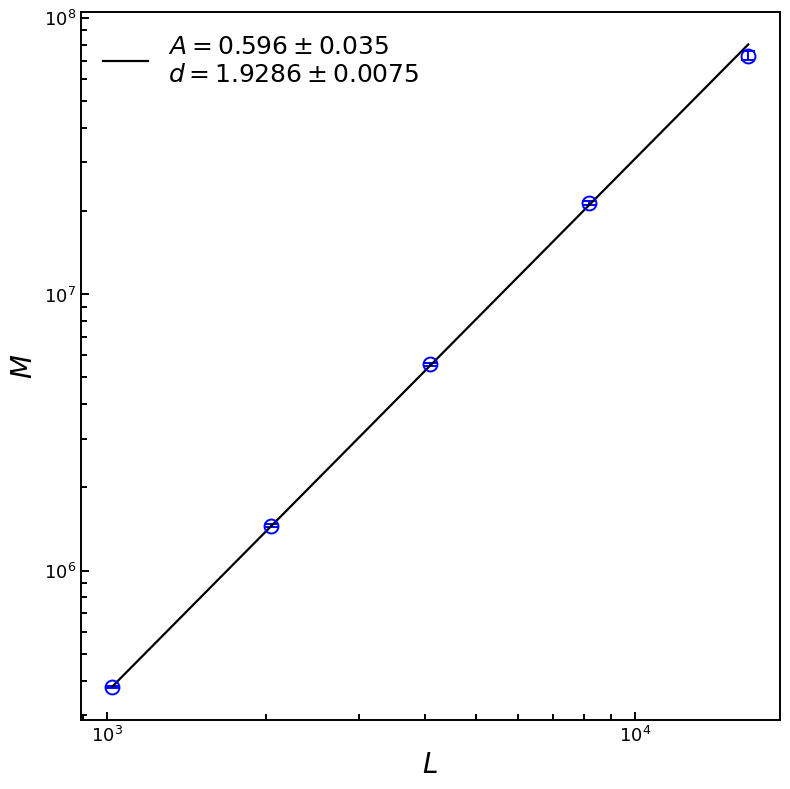

In [45]:
from scipy.optimize import curve_fit

# Dados
x = np.asarray(L_lst, dtype=float)
y = np.asarray(S_mean_node, dtype=float)
y_err = np.asarray(S_mean_node_err, dtype=float)

# Remove valores inválidos
mask = (
    np.isfinite(x) & np.isfinite(y) & np.isfinite(y_err)
    & (x > 0) & (y > 0) & (y_err > 0)
)

x = x[mask]
y = y[mask]
y_err = y_err[mask]

# Transformação log-log
x_log = np.log(x)
y_log = np.log(y)
y_log_err = y_err / y

# ln(M) = ln(A) + d ln(L)
def modelo_log(ln_L, ln_A, d):
    return ln_A + d * ln_L

popt, pcov = curve_fit(
    modelo_log,
    x_log,
    y_log,
    sigma=y_log_err,
    absolute_sigma=True
)

ln_A, d = popt
ln_A_err, d_err = np.sqrt(np.diag(pcov))

A = np.exp(ln_A)
A_err = A * ln_A_err

y_pred_log = modelo_log(x_log, ln_A, d)

r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

print(f"A = {A:.6f} +/- {A_err:.6e}")
print(f"d = {d:.6f} +/- {d_err:.6e}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

base = 4
fig, ax = plt.subplots(figsize=(2 * base, 2 * base))

ax.errorbar(
    x,
    y,
    yerr=y_err,
    fmt='o',
    ms=10,
    mec='blue',
    mfc='none',
    mew=1.4,
    ecolor='blue',
    elinewidth=1.4,
    capsize=5,
    capthick=1.4
)

ax.plot(
    L_fit,
    S_fit,
    '-',
    color='k',
    linewidth=1.6,
    label=legenda
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=20)
ax.set_ylabel(r'$M$', fontsize=20)

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    labelsize=13,
    length=6,
    width=1.4
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.4
)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

# Legenda sem caixa
ax.legend(
    fontsize=18,
    frameon=False,
    loc='upper left',
    handlelength=1.8
)

fig.tight_layout()
plt.show()

# Shortest Path

2397.54
5406.795454545455
12416.681818181818
28557.317567567567
68033.20588235294


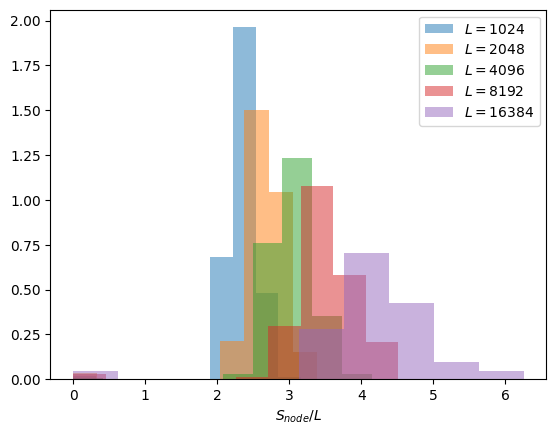

In [ ]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.0
prop = "SP_stab"
SP_mean = []
SP_mean_err = []

for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    SP_stab = values[(L, gap)][0]["data"][prop]
    norm = [i/L for i in SP_stab]
    SP_avarage = np.mean(SP_stab)

    SP_mean.append(SP_avarage)
    print(SP_avarage)
    plt.hist(norm,alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$S_{node}/L$')
plt.legend()
plt.show()

A = 0.555399
d = 1.205424
R² = 0.999864
RMSE(log) = 1.377679e-02


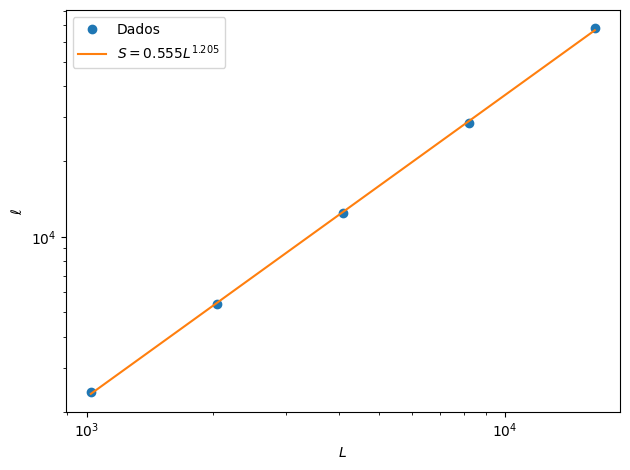

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.array(L_lst, dtype=float)
y = np.array(SP_mean_node, dtype=float)

# Transformação log-log
x_log = np.log(x).reshape(-1, 1)
y_log = np.log(y)

# Ajuste linear
model = LinearRegression()
model.fit(x_log, y_log)

# Predição no espaço log
y_pred_log = model.predict(x_log)

# Parâmetros
d = model.coef_[0]
log_A = model.intercept_
A = np.exp(log_A)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

print(f"A = {A:.6f}")
print(f"d = {d:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")

# Curva ajustada no espaço original
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

# Plot
plt.plot(x, y, 'o', label='Dados')
plt.plot(
    L_fit,
    S_fit,
    '-',
    label=fr'$S = {A:.3f}L^{{{d:.3f}}}$'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$L$')
plt.ylabel(r'$\ell$')

plt.legend()
plt.tight_layout()
plt.show()